In [2]:
! pip install xgboost -q

In [43]:
# import laibraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [44]:
# import the data
df = sns.load_dataset('diamonds')
df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [53]:
# split the data into X and y
X = df.drop('cut', axis=1)
y = df['cut']

# encode the target variable
le = LabelEncoder()
X['color'] = le.fit_transform(X['color'])
X['clarity'] = le.fit_transform(X['clarity'])
y = le.fit_transform(y)



# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
%%time
# train the decision tree model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# predict the test data
y_pred = dt_model.predict(X_test)

# evaluate the model
print("Decision Tree Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='micro'))
print("Recall:", recall_score(y_test, y_pred, average='micro'))
print("F1 Score:", f1_score(y_test, y_pred, average='micro'))

Decision Tree Classifier
Accuracy: 0.7182054134223211
Precision: 0.7182054134223211
Recall: 0.7182054134223211
F1 Score: 0.7182054134223211
CPU times: total: 609 ms
Wall time: 798 ms


In [55]:
%%time
# train the random forest model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
# predict the test data
y_pred = rf_model.predict(X_test)

# evaluate the model    
print("\nRandom Forest Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='micro'))  
print("Recall:", recall_score(y_test, y_pred, average='micro'))
print("F1 Score:", f1_score(y_test, y_pred, average='micro'))


Random Forest Classifier
Accuracy: 0.7877271041898406
Precision: 0.7877271041898406
Recall: 0.7877271041898406
F1 Score: 0.7877271041898406
CPU times: total: 14.4 s
Wall time: 16.3 s


In [56]:
%%time
# train the XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)

# predict the test data 
y_pred = model.predict(X_test)

# evaluate the model    
print("\nXGBoost Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='micro'))  
print("Recall:", recall_score(y_test, y_pred, average='micro'))  
print("F1 Score:", f1_score(y_test, y_pred, average='micro'))

c:\Users\nasik\miniconda3\envs\python_ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [05:48:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classifier
Accuracy: 0.8017241379310345
Precision: 0.8017241379310345
Recall: 0.8017241379310345
F1 Score: 0.8017241379310345
CPU times: total: 7.83 s
Wall time: 3.54 s


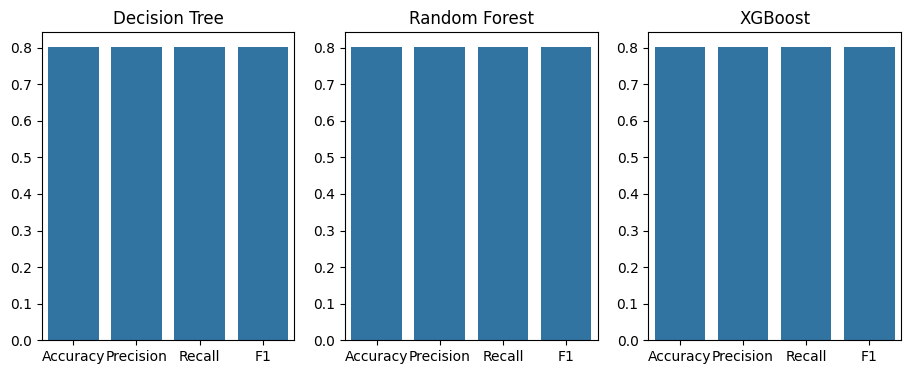

In [57]:
# make a bar plot showing each of the metrix with respect to the model 
# make a bar plot showing each of the matrix with respect to the model
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('Decision Tree')
plt.subplot(1, 4, 2)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('Random Forest')
plt.subplot(1, 4, 3)
sns.barplot(x=['Accuracy', 'Precision', 'Recall', 'F1'], y=[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='micro'), recall_score(y_test, y_pred, average='micro'), f1_score(y_test, y_pred, average='micro')])
plt.title('XGBoost')
# plt.tight_layout()
plt.show()